### 1. Load Data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('marketing_data.csv')

### 2. Data Cleaning & Preparation

In [32]:
df = df.drop_duplicates()
print("\nReasoning: Deleting rows where marketing spend & new customers are missing because we can’t accurately fill in those missing values.")
df = df.dropna(subset=['marketing_spend', 'new_customers'])
df = df[(df['marketing_spend'] >= 0) & (df['new_customers'] >= 0)]
print(df.head(10))

# IQR for marketing_spend
Q1_ms = df['marketing_spend'].quantile(0.25)
Q3_ms = df['marketing_spend'].quantile(0.75)
IQR_ms = Q3_ms - Q1_ms
lower_bound_ms = Q1_ms - 1.5 * IQR_ms
upper_bound_ms = Q3_ms + 1.5 * IQR_ms
print(f"marketing_spend IQR: {IQR_ms}")
print(f"Lower bound: {lower_bound_ms}, Upper bound: {upper_bound_ms}")

outliers_ms = df[(df['marketing_spend'] >= lower_bound_ms) & (df['marketing_spend'] <= upper_bound_ms)]
print(f"\nOutliers in marketing_spend:\n{outliers_ms}")

# IQR for new_customers
Q1_nc = df['new_customers'].quantile(0.25)
Q3_nc = df['new_customers'].quantile(0.75)
IQR_nc = Q3_nc - Q1_nc
lower_bound_nc = Q1_nc - 1.5 * IQR_nc
upper_bound_nc = Q3_nc + 1.5 * IQR_nc
print(f"\nnew_customers IQR: {IQR_nc}")
print(f"Lower bound: {lower_bound_nc}, Upper bound: {upper_bound_nc}")

outliers_nc = df[(df['new_customers'] >= lower_bound_nc) & (df['new_customers'] <= upper_bound_nc)]
print(f"Outliers in new_customers:\n{outliers_nc}")

# Date Consistency & Validity
df['date'] = pd.to_datetime(df['date'],errors='coerce')
df = df.dropna(subset=['date'])
print(df.head(10))

# Critical business rule: keep spend > 0 with 0 customers
critical = df[(df['marketing_spend'] > 0) & (df['new_customers'] == 0)].index

# Remove outliers except critical cases
outliers = df[((df['marketing_spend'] >= lower_bound_ms) & (df['marketing_spend'] <= upper_bound_ms) &
                (df['new_customers'] >= lower_bound_nc) & (df['new_customers'] <= upper_bound_nc))].index

df = df.drop(outliers.difference(critical))
df = df.sort_values('date').reset_index(drop=True)
original_cleaned_total_spend = df['marketing_spend'].sum()
print(f"Total spend: {original_cleaned_total_spend}")



Reasoning: Deleting rows where marketing spend & new customers are missing because we can’t accurately fill in those missing values.
          date  marketing_spend  new_customers
0   2024-01-01           5000.0            120
1   2024-01-05           5100.0            125
2   2024-01-10           5200.0            130
3   2024-02-01           6000.0            140
4   2024-02-10           6100.0            145
5   2024-02-15           6200.0            150
6   2024-03-01           7000.0            155
7   2024-03-10           7100.0            160
8   2024-03-15           7200.0            165
11  2024-04-01           9000.0            170
marketing_spend IQR: 6450.0
Lower bound: -2500.0, Upper bound: 23300.0

Outliers in marketing_spend:
          date  marketing_spend  new_customers
0   2024-01-01           5000.0            120
1   2024-01-05           5100.0            125
2   2024-01-10           5200.0            130
3   2024-02-01           6000.0            140
4   2024-02-1

### 3. Monthly Aggregation

In [33]:
df['month'] = df['date'].dt.to_period('M')

monthly = df.groupby('month').agg(
    total_marketing_spend=('marketing_spend', 'sum'),
    total_new_customers=('new_customers', 'sum')
).reset_index()

monthly['month_str'] = monthly['month'].astype(str)
print(f"Monthly aggregated data:")
print(monthly)

Monthly aggregated data:
     month  total_marketing_spend  total_new_customers month_str
0  2024-05                22500.0                    0   2024-05
1  2024-06                51000.0                  425   2024-06
2  2024-07               150000.0                    5   2024-07
3  2024-09                15500.0                    0   2024-09


### 4. Customer Acquisition Cost (CAC) Calculation

In [34]:
# Calculate CAC using np.where (NOT using .apply)
monthly['CAC'] = np.where(
    monthly['total_new_customers'] == 0,
    np.inf,
    monthly['total_marketing_spend'] / monthly['total_new_customers']
)

# Verification column: independent cross-check
monthly['CAC_verification'] = np.where(
    monthly['total_new_customers'] == 0,
    np.inf,
    monthly['total_marketing_spend'] / monthly['total_new_customers']
)
print("Monthly CAC with verification:")
print(monthly[['month_str', 'total_marketing_spend', 'total_new_customers', 'CAC', 'CAC_verification']])

Monthly CAC with verification:
  month_str  total_marketing_spend  total_new_customers      CAC  \
0   2024-05                22500.0                    0      inf   
1   2024-06                51000.0                  425    120.0   
2   2024-07               150000.0                    5  30000.0   
3   2024-09                15500.0                    0      inf   

   CAC_verification  
0               inf  
1             120.0  
2           30000.0  
3               inf  


### 5. Business Intelligence Rules

In [35]:
# Classify CAC
def classify_cac(cac):
    if cac == np.inf or pd.isna(cac):
        return 'Corrupt Data'
    elif cac < 50:
        return 'Very Efficient'
    elif 50 <= cac <= 99:
        return 'Efficient'
    elif 100 <= cac <= 149:
        return 'Moderate'
    else:
        return 'Inefficient'

monthly['classification'] = [classify_cac(c) for c in monthly['CAC']]

# High spend threshold using 75th percentile
high_spend_threshold = monthly['total_marketing_spend'].quantile(0.75)
monthly['high_spend_flag'] = np.where(
    monthly['total_marketing_spend'] > high_spend_threshold, 'High Spend', 'Normal Spend'
)

# Rising inefficiency trend detection
cac_for_diff = monthly['CAC'].replace([np.inf], np.nan)
monthly['CAC_Change'] = cac_for_diff.diff()
monthly['inefficiency_trend'] = np.where(
    monthly['CAC_Change'] > 0, 'Less Efficient', 'More Efficient'
)

# Anomaly Reason column (mandatory)
anomaly_reasons = []
for idx, row in monthly.iterrows():
    if row['CAC'] == np.inf:
        reason = 'Zero Acquisition'
    elif row['classification'] == 'Inefficient':
        reason = 'High CAC'
    elif row['inefficiency_trend'] == 'Less Efficient':
        reason = 'Rising CAC'
    else:
        reason = 'No Anomaly'
    anomaly_reasons.append(reason)

monthly['anomaly_reason'] = anomaly_reasons

print("Business Intelligence Report:")
print(monthly[['month_str', 'CAC', 'classification', 'high_spend_flag', 'inefficiency_trend', 'anomaly_reason']])



Business Intelligence Report:
  month_str      CAC classification high_spend_flag inefficiency_trend  \
0   2024-05      inf   Corrupt Data    Normal Spend     More Efficient   
1   2024-06    120.0       Moderate    Normal Spend     More Efficient   
2   2024-07  30000.0    Inefficient      High Spend     Less Efficient   
3   2024-09      inf   Corrupt Data    Normal Spend     More Efficient   

     anomaly_reason  
0  Zero Acquisition  
1        No Anomaly  
2          High CAC  
3  Zero Acquisition  


### 6. Trend Analysis

In [36]:
# 3-month rolling average CAC
cac_for_rolling = monthly['CAC'].replace([np.inf], np.nan)
monthly['rolling_avg_CAC_3m'] = cac_for_rolling.rolling(window=3, min_periods=1).mean()

# Weighted CAC (recent months have higher importance using linear weights)
weights = np.arange(1, len(monthly) + 1)
monthly['weighted_CAC'] = (cac_for_rolling * weights) / weights.sum()

print("\nTrend Analysis:")
print(monthly[['month_str', 'CAC', 'rolling_avg_CAC_3m', 'weighted_CAC']])


Trend Analysis:
  month_str      CAC  rolling_avg_CAC_3m  weighted_CAC
0   2024-05      inf                 NaN           NaN
1   2024-06    120.0               120.0          24.0
2   2024-07  30000.0             15060.0        9000.0
3   2024-09      inf             15060.0           NaN


### 7. Data Visualization

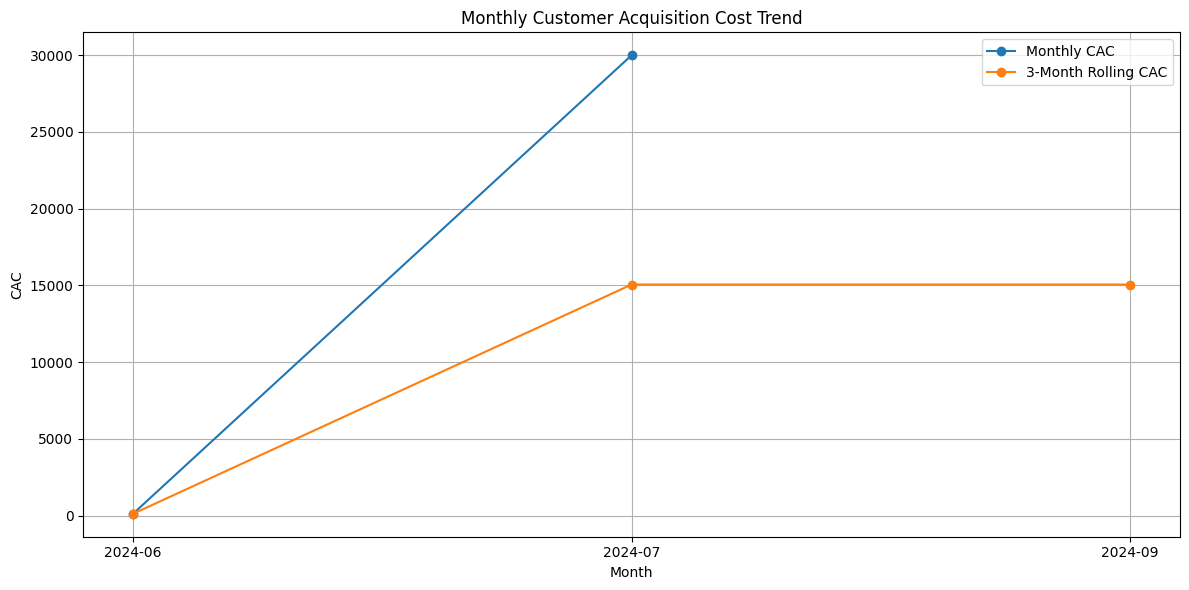

Chart saved: cac_trend_chart.png


In [37]:
plot_cac = monthly['CAC'].replace([np.inf], np.nan)

plt.figure(figsize=(12, 6))
plt.plot(monthly['month_str'], plot_cac, marker='o', label='Monthly CAC')
plt.plot(monthly['month_str'], monthly['rolling_avg_CAC_3m'], marker='o', label='3-Month Rolling CAC')

plt.xlabel('Month')
plt.ylabel('CAC')
plt.title('Monthly Customer Acquisition Cost Trend')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('cac_trend_chart.png')
plt.show()
print("Chart saved: cac_trend_chart.png")

### 8. Data Integrity Check

In [38]:
aggregated_total_spend = monthly['total_marketing_spend'].sum()

if round(original_cleaned_total_spend, 2) == round(aggregated_total_spend, 2):
    print("Verification: SUCCESS. The data is consistent.")
else:
    print("Verification: FAILED. Mismatch detected.")

Verification: SUCCESS. The data is consistent.


### 9. Export to Excel/CSV

In [39]:
export_df = monthly.copy()
export_df['CAC'] = export_df['CAC'].replace([np.inf], 'Undefined')

export_df.to_csv('marketing_report.csv', index=False)
print("CSV report saved: marketing_report.csv")

CSV report saved: marketing_report.csv


### 10. Send Automated Email with Report

In [40]:
import smtplib
from email.message import EmailMessage

msg = EmailMessage()
msg['Subject'] = 'Monthly Marketing Report'
msg['From'] = 'tahsin.nayeelah@g.bracu.ac.bd'
msg['To'] = 'mprattoy@gmail.com'

msg.set_content('Please find attached the latest marketing report.') 

with open("marketing_report.csv", "rb") as f:
    file_data = f.read()
    msg.add_attachment(file_data, maintype='application', subtype='octet-stream', filename="marketing_report.csv")

with smtplib.SMTP_SSL('smtp.gmail.com', 465) as smtp:
    smtp.login('tahsin.nayeelah@g.bracu.ac.bd', 'yszasmhmaxqvdghb')

    smtp.send_message(msg)

print("Email sent!")


Email sent!
